In [1]:
import numpy as np

tensor_a = np.array([[1, 2, 3], [4, 5, 6]])
tensor_b = np.array([[6, 5, 4], [3, 2, 1]])

print("Tensor A:\n", tensor_a)
print("Tensor B:\n", tensor_b)


Tensor A:
 [[1 2 3]
 [4 5 6]]
Tensor B:
 [[6 5 4]
 [3 2 1]]


In [2]:

addition_result = tensor_a + tensor_b
print("Element-wise Addition:\n", addition_result)


Element-wise Addition:
 [[7 7 7]
 [7 7 7]]


In [3]:

multiplication_result = tensor_a * tensor_b
print("Element-wise Multiplication:\n", multiplication_result)


Element-wise Multiplication:
 [[ 6 10 12]
 [12 10  6]]


In [4]:

reshaped_tensor = tensor_a.reshape(3, 2)
print("Reshaped Tensor (3x2):\n", reshaped_tensor)


Reshaped Tensor (3x2):
 [[1 2]
 [3 4]
 [5 6]]


In [5]:

sliced_tensor = tensor_a[0, :]
print("Sliced Tensor (First Row):\n", sliced_tensor)

indexed_element = tensor_a[1, 2]
print("Indexed Element (2nd row, 3rd column):", indexed_element)


Sliced Tensor (First Row):
 [1 2 3]
Indexed Element (2nd row, 3rd column): 6


In [6]:

combined_tensor_vertical = np.vstack((tensor_a, tensor_b))
print("Vertical Stack of Tensors:\n", combined_tensor_vertical)

combined_tensor_horizontal = np.hstack((tensor_a, tensor_b))
print("Horizontal Stack of Tensors:\n", combined_tensor_horizontal)


Vertical Stack of Tensors:
 [[1 2 3]
 [4 5 6]
 [6 5 4]
 [3 2 1]]
Horizontal Stack of Tensors:
 [[1 2 3 6 5 4]
 [4 5 6 3 2 1]]


In [7]:

split_tensors = np.split(tensor_a, 2, axis=0)
print("Splitted Tensors:\n", split_tensors)

split_tensors_columns = np.split(tensor_a, 3, axis=1)
print("Splitted Tensors (Columns):\n", split_tensors_columns)


Splitted Tensors:
 [array([[1, 2, 3]]), array([[4, 5, 6]])]
Splitted Tensors (Columns):
 [array([[1],
       [4]]), array([[2],
       [5]]), array([[3],
       [6]])]


In [8]:

addition = tensor_a + 10
print("Tensor A + 10:\n", addition)

subtraction = tensor_a - 5
print("Tensor A - 5:\n", subtraction)

multiplication = tensor_a * 2
print("Tensor A * 2:\n", multiplication)

division = tensor_a / 2
print("Tensor A / 2:\n", division)


Tensor A + 10:
 [[11 12 13]
 [14 15 16]]
Tensor A - 5:
 [[-4 -3 -2]
 [-1  0  1]]
Tensor A * 2:
 [[ 2  4  6]
 [ 8 10 12]]
Tensor A / 2:
 [[0.5 1.  1.5]
 [2.  2.5 3. ]]


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(5, input_dim=3, activation='relu'))  

model.add(Dense(1, activation='linear'))  
print("Model defined successfully!")


2025-02-03 19:54:51.608014: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Model defined successfully!


2025-02-03 19:55:08.834542: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

print("Model compiled successfully!")


Model compiled successfully!


In [11]:

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 5)                 20        
                                                                 
 dense_1 (Dense)             (None, 1)                 6         
                                                                 
Total params: 26
Trainable params: 26
Non-trainable params: 0
_________________________________________________________________


classification

In [38]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255


y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)




In [27]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

maxlen = 500
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)




In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense

model_mnist = Sequential()
model_mnist.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))  
model_mnist.add(Flatten())  
model_mnist.add(Dense(128, activation='relu'))  
model_mnist.add(Dense(10, activation='softmax'))  




In [28]:

model_imdb = Sequential()
model_imdb.add(Embedding(input_dim=10000, output_dim=128, input_length=500))  
model_imdb.add(Flatten()) 
model_imdb.add(Dense(128, activation='relu'))  
model_imdb.add(Dense(1, activation='sigmoid'))  




In [40]:

model_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])




In [30]:

model_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



In [41]:

history_mnist = model_mnist.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))




Epoch 1/10
938/938 [==============================] - 71s 75ms/step - loss: 0.1473 - accuracy: 0.9560 - val_loss: 0.0595 - val_accuracy: 0.9808
Epoch 2/10
938/938 [==============================] - 69s 74ms/step - loss: 0.0440 - accuracy: 0.9869 - val_loss: 0.0566 - val_accuracy: 0.9820
Epoch 3/10
938/938 [==============================] - 72s 77ms/step - loss: 0.0226 - accuracy: 0.9929 - val_loss: 0.0663 - val_accuracy: 0.9784
Epoch 4/10
938/938 [==============================] - 75s 80ms/step - loss: 0.0135 - accuracy: 0.9958 - val_loss: 0.0492 - val_accuracy: 0.9856
Epoch 5/10
938/938 [==============================] - 78s 84ms/step - loss: 0.0085 - accuracy: 0.9973 - val_loss: 0.0586 - val_accuracy: 0.9829
Epoch 6/10
938/938 [==============================] - 82s 87ms/step - loss: 0.0077 - accuracy: 0.9972 - val_loss: 0.0581 - val_accuracy: 0.9852
Epoch 7/10
938/938 [==============================] - 85s 91ms/step - loss: 0.0067 - accuracy: 0.9978 - val_loss: 0.0842 - val_accuracy:

In [31]:

history_imdb = model_imdb.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))



Epoch 1/10
391/391 [==============================] - 78s 196ms/step - loss: 0.4013 - accuracy: 0.8054 - val_loss: 0.2922 - val_accuracy: 0.8782
Epoch 2/10
391/391 [==============================] - 78s 199ms/step - loss: 0.0788 - accuracy: 0.9751 - val_loss: 0.3596 - val_accuracy: 0.8640
Epoch 3/10
391/391 [==============================] - 85s 216ms/step - loss: 0.0070 - accuracy: 0.9992 - val_loss: 0.4353 - val_accuracy: 0.8697
Epoch 4/10
391/391 [==============================] - 87s 222ms/step - loss: 7.1164e-04 - accuracy: 1.0000 - val_loss: 0.4870 - val_accuracy: 0.8712
Epoch 5/10
391/391 [==============================] - 81s 208ms/step - loss: 2.3531e-04 - accuracy: 1.0000 - val_loss: 0.5150 - val_accuracy: 0.8713
Epoch 6/10
391/391 [==============================] - 83s 211ms/step - loss: 1.2551e-04 - accuracy: 1.0000 - val_loss: 0.5377 - val_accuracy: 0.8721
Epoch 7/10
391/391 [==============================] - 89s 227ms/step - loss: 7.9612e-05 - accuracy: 1.0000 - val_loss:

In [42]:

test_loss_mnist, test_acc_mnist = model_mnist.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss_mnist}, Test Accuracy: {test_acc_mnist}")




313/313 [==============================] - 4s 11ms/step - loss: 0.0728 - accuracy: 0.9843
Test Loss: 0.07282515615224838, Test Accuracy: 0.9843000173568726


In [34]:

test_loss_imdb, test_acc_imdb = model_imdb.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss_imdb}, Test Accuracy: {test_acc_imdb}")


782/782 [==============================] - 15s 19ms/step - loss: 0.6065 - accuracy: 0.8725
Test Loss: 0.6064711213111877, Test Accuracy: 0.8725200295448303


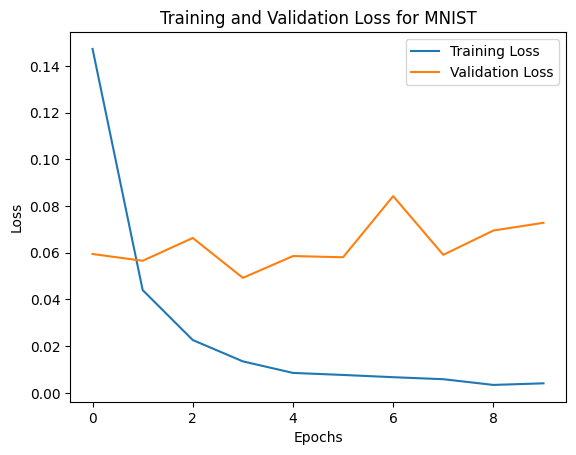

In [43]:
import matplotlib.pyplot as plt

plt.plot(history_mnist.history['loss'], label='Training Loss')
plt.plot(history_mnist.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for MNIST')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


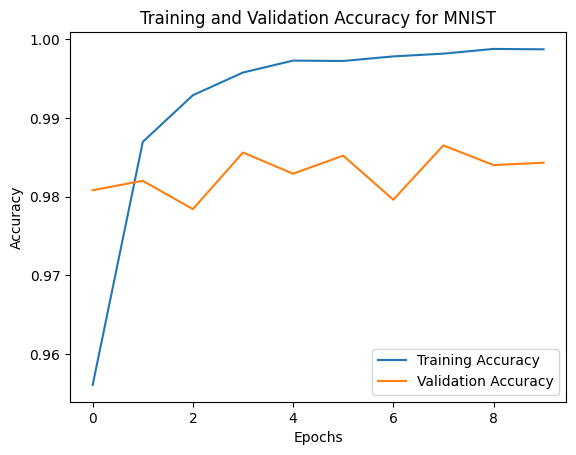

In [44]:

plt.plot(history_mnist.history['accuracy'], label='Training Accuracy')
plt.plot(history_mnist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy for MNIST')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


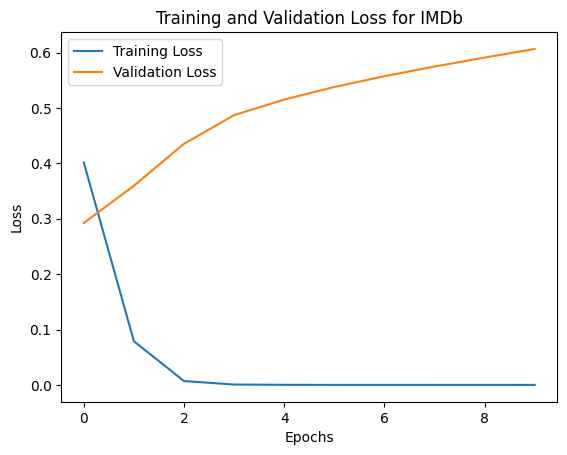

In [35]:
import matplotlib.pyplot as plt

plt.plot(history_imdb.history['loss'], label='Training Loss')
plt.plot(history_imdb.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss for IMDb')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


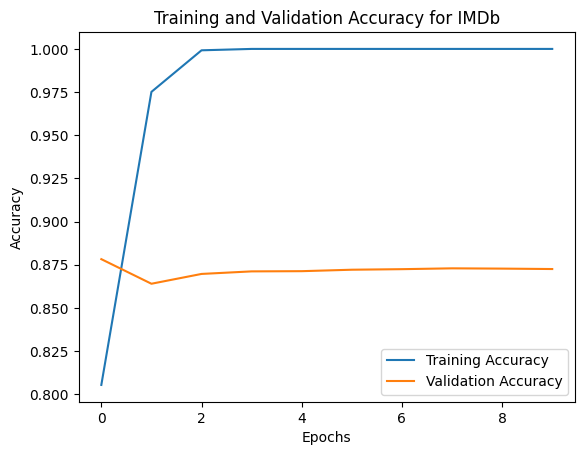

In [36]:

plt.plot(history_imdb.history['accuracy'], label='Training Accuracy')
plt.plot(history_imdb.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy for IMDb')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
